In [ ]:
print("Setup Successful!")

In [ ]:
%pip3 install pandas scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd

# Data load kar rahe hain
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Check karte hain ki data kaisa dikhta hai (Top 5 rows)
df.head()

In [ ]:
# 1. 'TotalCharges' ko number mein convert karte hain
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Jo khali rows hain (Missing values), unhe hata dete hain
df.dropna(inplace=True)

# 3. 'customerID' column hamare kisi kaam ka nahi hai prediction ke liye, usey delete karte hain
df.drop('customerID', axis=1, inplace=True)

# Check karte hain ki sab theek hai
df.info()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dekhte hain kitne log Churn (Yes) hue aur kitne (No)
sns.countplot(x='Churn', data=df)
plt.title('Churn Count (No vs Yes)')
plt.show()

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Jo columns 'Yes/No' wale hain, unhe 1 aur 0 bana dete hain
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object' and len(df[col].unique()) <= 2:
        df[col] = le.fit_transform(df[col])

# 2. Baki bache hue text columns ko numbers mein badalte hain (One-Hot Encoding)
df = pd.get_dummies(df)

# 3. Data ko do hisson mein baantte hain: 
# X = Features (Inputs jaise tenure, charges)
# y = Target (Jo humein predict karna hai yani 'Churn')
X = df.drop('Churn', axis=1)
y = df['Churn']

# 4. Train-Test Split: 80% data se model seekhega, 20% par hum uska exam lenge
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data ready hai! Train set size:", X_train.shape)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Model ko bulate hain
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Model ko 'Train' karte hain (Isse machine seekhegi)
model.fit(X_train, y_train)

# 3. Ab machine ka test lete hain (Predictions)
y_pred = model.predict(X_test)

# 4. Result dekhte hain
print("Model ki Accuracy hai:", accuracy_score(y_test, y_pred))
print("\nDetailed Report:\n", classification_report(y_test, y_pred))

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# 2. Encoding (Text to Numbers)
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object' and len(df[col].unique()) <= 2:
        df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df)

# 3. Splitting (X aur y banana)
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Ab sab set hai! X_train ready hai.")

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load Data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# 3. Explicit Encoding (Ye line magic hai!)
# 'Yes' ko 1 aur 'No' ko 0 mein badal rahe hain bina column ka naam badle
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# 4. Baaki bache hue text columns ko numbers mein badalte hain
df = pd.get_dummies(df)

# 5. Splitting
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Model Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 7. Final Result
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7775408670931059


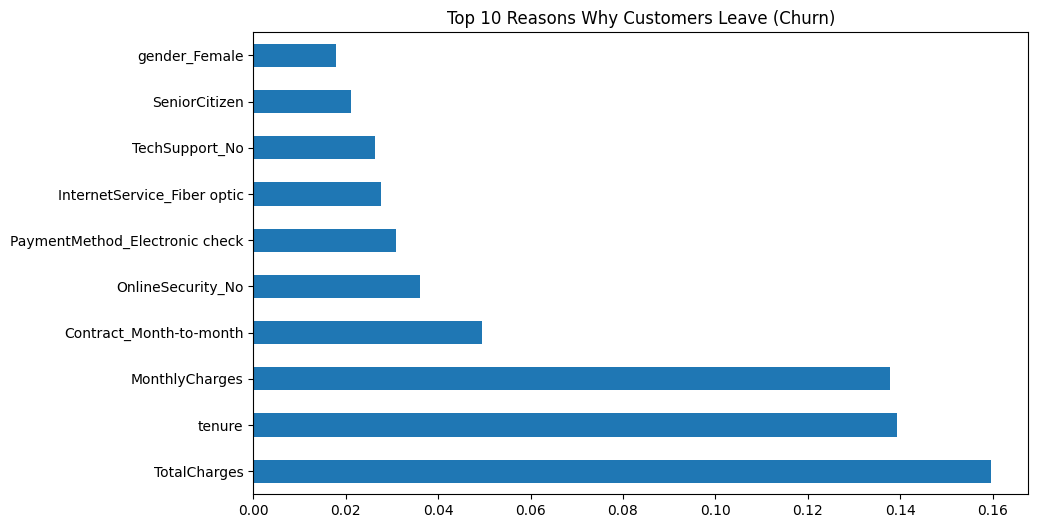

In [3]:
import matplotlib.pyplot as plt

# Model se puchte hain ki sabse important features kaunse hain
importances = pd.Series(model.feature_importances_, index=X.columns)

# Top 10 reasons dikhao
importances.nlargest(10).plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Reasons Why Customers Leave (Churn)')
plt.show()